# Cross-Correlation Analysis

This notebook computes the cross-correlation functions between mass concentration and hydraulic head for specifically chosen nodes. The goal is to investigate whether the model (GINO) creates artificial coupling between mass concentration and hydraulic head beyond what the PDE dictates.

We select nodes where the ground truth (FEFLOW) solution is completely stable (low variance), but the model predictions show high-frequency artificial variations.

In [19]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Define results directory and load data
results_dir = os.path.expanduser('~/OneDrive - The University of Sydney (Staff)/Shared/Projects/01_PhD/03_Physics_Informed/05_groundwater/groundwater_main/results/')
# results_dir = os.path.join(results_dir, 'updated_lowres', 'resolution_1.0/gino_predictions_20260326_161714')
results_dir = os.path.join(results_dir, 'updated_lowres', 'resolution_0.167/gino_predictions_20260326_162706')

val_preds = np.load(os.path.join(results_dir, 'val_predictions.npy'))
val_targets = np.load(os.path.join(results_dir, 'val_targets.npy'))

if len(val_preds.shape) == 4:
    preds = np.squeeze(val_preds, axis=2).transpose(1, 0, 2)
    targets = np.squeeze(val_targets, axis=2).transpose(1, 0, 2)
else:
    preds = val_preds
    targets = val_targets

print(f"Predictions shape: {preds.shape}")
print(f"Targets shape: {targets.shape}")

Predictions shape: (10240, 568, 2)
Targets shape: (10240, 568, 2)


## 1. Identify Nodes of Interest
Find nodes with low true variance but high high-frequency predicted variance for mass concentration.

In [ ]:
# Separate variables
target_mass_conc = targets[:, :, 0]
pred_mass_conc = preds[:, :, 0]
target_head = targets[:, :, 1]
pred_head = preds[:, :, 1]

# High-frequency variation = variance of first derivative
target_var = np.var(np.diff(target_mass_conc, axis=1), axis=1)
pred_var = np.var(np.diff(pred_mass_conc, axis=1), axis=1)

# "Close to zero" metric for target mass concentration
target_level = np.mean(np.abs(target_mass_conc), axis=1)

# Primary thresholds
var_thresh = np.percentile(target_var, 5)
zero_tol = 1e-2  # adjust as needed for your units

mask_var = target_var <= var_thresh
mask_zero = target_level <= zero_tol
mask = mask_var & mask_zero

# Fallback if too few nodes pass strict zero tolerance
if np.sum(mask) < 2:
    level_thresh = np.percentile(target_level, 5)  # lowest-magnitude targets
    mask = mask_var & (target_level <= level_thresh)
    print(f"Fallback used: target_level <= {level_thresh:.4g}")

valid_indices = np.where(mask)[0]

# Shuffle valid nodes and pick 2
rng = np.random.default_rng(42)
sorted_nodes = rng.permutation(valid_indices)

selected_nodes = sorted_nodes[:2]
print(f"Selected Nodes: {selected_nodes}")
print(f"Candidates found: {len(valid_indices)}")

Selected Nodes: [8089  957]


## 2. Compute and Plot Cross-Correlation
Compute cross-correlation of Concentration vs. Head. We'll visualize the timeseries themselves alongside the normalized Cross-Correlation Function.

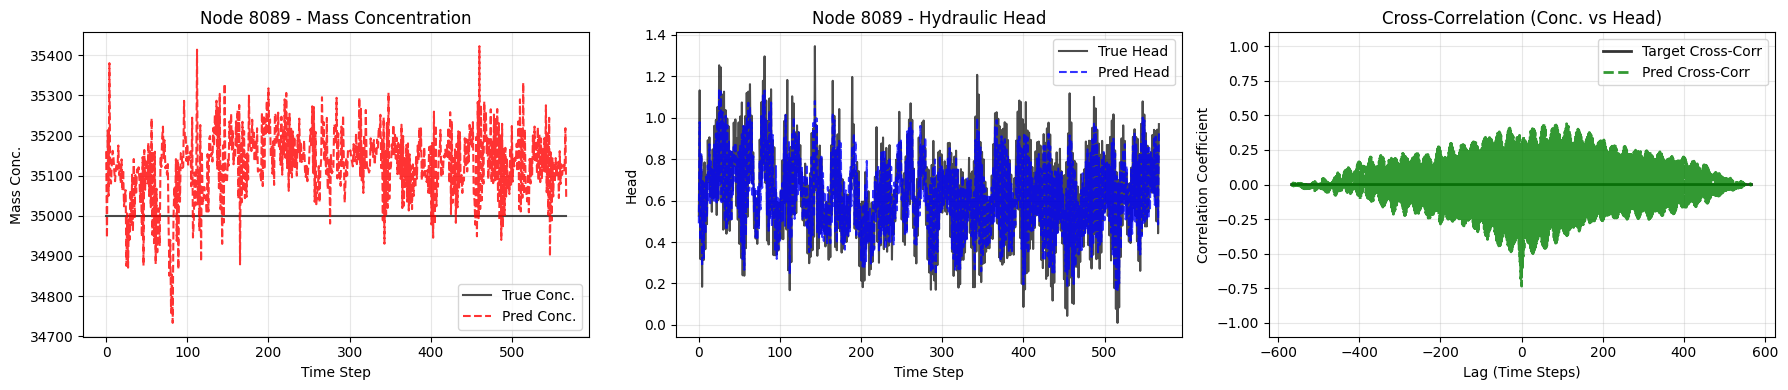

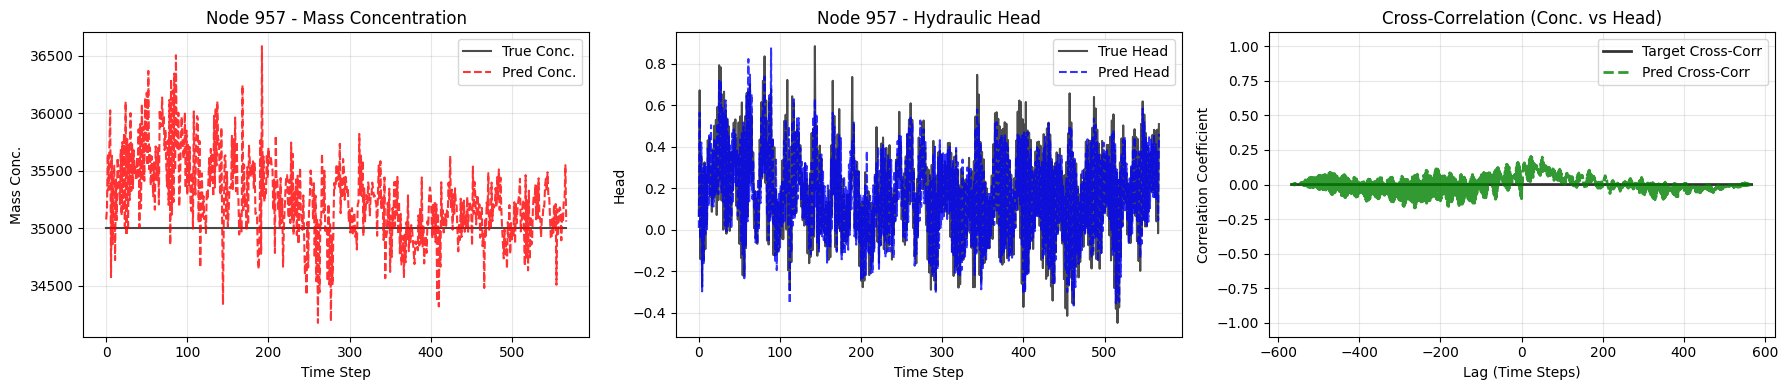

In [21]:
def compute_cross_correlation(series_a, series_b):
    """
    Computes normalized cross-correlation between two 1D series.
    Returns lags and the correlation array.
    """
    # Subtract means to avoid zero-frequency inflation
    a_norm = series_a - np.mean(series_a)
    b_norm = series_b - np.mean(series_b)
    
    # Standardize to get correlation between -1 and 1
    a_std = np.std(a_norm)
    b_std = np.std(b_norm)
    if a_std == 0 or b_std == 0:
        # If one series is perfectly constant, correlation is technically undefined (returns 0s)
        return signal.correlation_lags(len(series_a), len(series_b)), np.zeros(2*len(series_a)-1)
        
    a_norm = a_norm / a_std
    b_norm = b_norm / b_std
    
    # Compute full cross-correlation
    cc = signal.correlate(a_norm, b_norm, mode='full')
    # Normalize by Length
    cc /= len(series_a)
    
    lags = signal.correlation_lags(len(series_a), len(series_b))
    return lags, cc

for idx, node in enumerate(selected_nodes):
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    
    # -- 1. Plot Mass Concentration --
    axes[0].plot(target_mass_conc[node], 'k-', label='True Conc.', alpha=0.7)
    axes[0].plot(pred_mass_conc[node], 'r--', label='Pred Conc.', alpha=0.8)
    axes[0].set_title(f"Node {node} - Mass Concentration")
    axes[0].set_xlabel("Time Step")
    axes[0].set_ylabel("Mass Conc.")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # -- 2. Plot Hydraulic Head --
    axes[1].plot(target_head[node], 'k-', label='True Head', alpha=0.7)
    axes[1].plot(pred_head[node], 'b--', label='Pred Head', alpha=0.8)
    axes[1].set_title(f"Node {node} - Hydraulic Head")
    axes[1].set_xlabel("Time Step")
    axes[1].set_ylabel("Head")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # -- 3. Cross-Correlation --
    true_lags, true_cc = compute_cross_correlation(target_mass_conc[node], target_head[node])
    pred_lags, pred_cc = compute_cross_correlation(pred_mass_conc[node], pred_head[node])
    
    axes[2].plot(true_lags, true_cc, 'k-', label='Target Cross-Corr', lw=2, alpha=0.8)
    axes[2].plot(pred_lags, pred_cc, 'g--', label='Pred Cross-Corr', lw=2, alpha=0.8)
    axes[2].set_title("Cross-Correlation (Conc. vs Head)")
    axes[2].set_xlabel("Lag (Time Steps)")
    axes[2].set_ylabel("Correlation Coefficient")
    axes[2].set_ylim(-1.1, 1.1)
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()